In [1]:
import io
import os
import fnmatch
from typing import List, Optional
import paramiko
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

def load_features_importance(ip: str,
                             user: str,
                             password: str,
                            remote_dir: str,
                            model: str 
                            ) -> Optional[pd.DataFrame]:
    
    transport = None
    sftp = None
    remote_dir = remote_dir + '/' + model
    try:
        # Establish SFTP connection
        transport = paramiko.Transport((ip, 22))
        transport.connect(username=user, password=password)
        sftp = paramiko.SFTPClient.from_transport(transport)

        # List files in the remote directory
        files = sftp.listdir(remote_dir)
        pattern = f"features_importance.pkl"
        matched_files = fnmatch.filter(files, pattern)

        if not matched_files:
            print(f"No files matching pattern {pattern} found in {remote_dir}")
            return None
        
        # Sort files by modification time and get the latest one
        matched_files.sort(key=lambda x: sftp.stat(os.path.join(remote_dir, x)).st_mtime, reverse=True)
        latest_file = matched_files[0]
        remote_file_path = os.path.join(remote_dir, latest_file)

        # Read the CSV file into a pandas DataFrame
        with sftp.open(remote_file_path, "rb") as f:
            obj = pickle.load(f)

        if isinstance(obj, pd.DataFrame):
            return obj
        try:
            return pd.DataFrame(obj)
        except Exception as e:
            print("Le pickle n'est pas un DataFrame et n'est pas convertible en DataFrame.")
            return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    
    finally:
        # Fermeture propre
        try:
            if sftp is not None:
                sftp.close()
        finally:
            if transport is not None:
                transport.close()

In [2]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"
model = "catboost_search_full_10_all_one_burnedarea-kmeans-5-Class-Dept_classification_softmax"

features_importance = load_features_importance(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    model=model
)

In [3]:
features_importance

,mean_abs_shap,stdev_abs_shap,name,class
5,0.198347,1.076795e-01,id_encoder,0
12,0.171373,9.229991e-02,rhum_mean,0
161,0.101302,1.220579e-01,Past_risk,0
3,0.096920,6.964073e-02,fwi_max,0
24,0.095458,5.216393e-02,cluster_encoder,0
...,...,...,...,...
144,0.000008,1.194510e-04,snow24h_min,4
92,0.000002,3.306824e-05,sum_consecutive_rainfall_min,4
78,0.000002,1.886299e-05,snow24h16_min,4
156,0.000001,3.955389e-07,kbdi_min,4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_features_importance_abs_mean_by_class(
    df: pd.DataFrame,
    top_n: int = 20,
    value_col: str = "mean_abs_shap",
    feature_col: str = "name",
    class_col: str = "class",
    annotate: bool = True,
    cmap_name: str = "viridis",  # ex: "viridis", "plasma", "inferno", "magma", "cividis", "tab20"
    rotate_xticks: int = 45
):
    """
    Calcule Mean(|SHAP|) moyenné par classe puis entre classes pour chaque feature,
    sélectionne le Top-N et trace un barplot vertical (features sur l'axe X) avec un colormap.

    Paramètres
    ----------
    df : DataFrame avec colonnes [value_col, feature_col, class_col]
    top_n : nombre de features affichées
    annotate : affiche la valeur au-dessus de chaque barre
    cmap_name : colormap matplotlib pour colorer les barres
    rotate_xticks : rotation des labels X (degrés)

    Retour
    ------
    fig, ax, top_series
    """
    expected = {value_col, feature_col, class_col}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes: {missing}. Requises: {expected}")

    work = df[[value_col, feature_col, class_col]].dropna(subset=[value_col, feature_col, class_col]).copy()
    work["abs_val"] = work[value_col].abs()

    # Moyenne par (feature, classe)
    class_means = work.groupby([feature_col, class_col], dropna=False)["abs_val"].mean()

    # Moyenne entre classes (par feature)
    feature_means = class_means.groupby(level=0).mean().sort_values(ascending=False)

    # Top-N (garder l'ordre décroissant pour l'affichage de gauche à droite)
    top_series = feature_means.head(top_n)

    # Préparer les couleurs en fonction des valeurs
    vals = top_series.values
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    # éviter division par zéro si toutes valeurs identiques
    normed = (vals - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(vals)
    cmap = cm.get_cmap(cmap_name)
    colors = cmap(normed)

    # Taille de figure adaptée au nombre de barres
    width = max(6.0, 0.6 * len(top_series) + 1.5)
    fig, ax = plt.subplots(figsize=(width, 5.5))

    bars = ax.bar(top_series.index.astype(str), top_series.values, color=colors, edgecolor="none")

    ax.set_ylabel("Mean(|SHAP|)")
    ax.set_xlabel("Feature")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    # Rotation/ajustement des labels X
    if rotate_xticks:
        plt.setp(ax.get_xticklabels(), rotation=rotate_xticks, ha="right")

    # Annotations
    if annotate:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{v:.4g}",
                    ha="center", va="bottom")

    plt.tight_layout()
    return fig, ax, top_series

/tmp/ipykernel_28550/3943753749.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


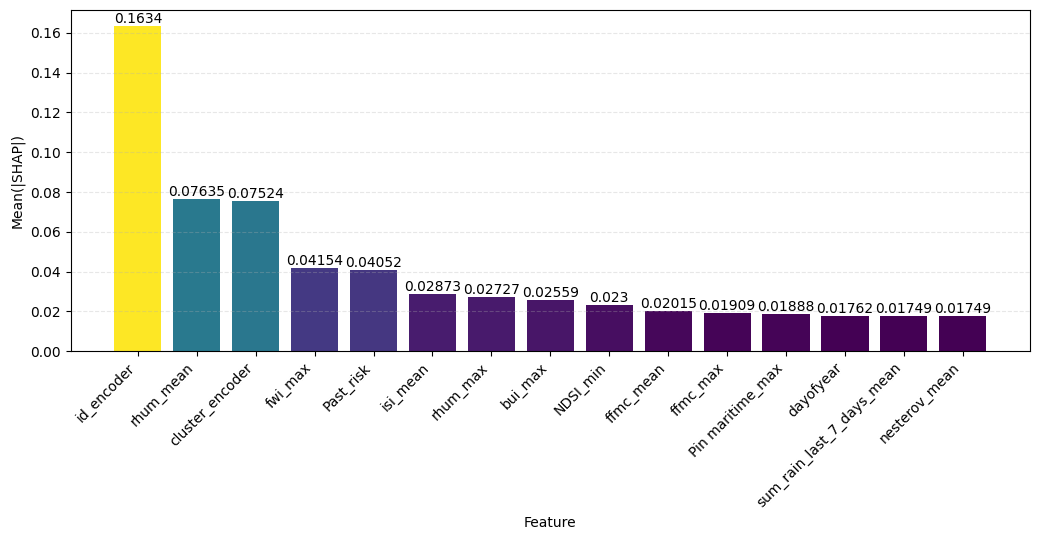

In [5]:
fig, ax, top_vals = plot_features_importance_abs_mean_by_class(features_importance, top_n=15)

In [12]:
features_importance_0 = features_importance[features_importance['class'] == 0]

In [13]:
for name in features_importance_0.name:
    print(name)

id_encoder
rhum_mean
Past_risk
fwi_max
cluster_encoder
isi_mean
rhum_max
bui_max
ffmc_mean
ffmc_max
dayofyear
sum_rain_last_7_days_mean
nesterov_mean
NDSI_min
calendar_sum
calendar_min
prec24h_max
angstroem_mean
sum_rain_last_7_days_max
munger_mean
dc_max
month
calendar_max
nesterov_max
rhum16_mean
precipitationIndexN5_max
precipitationIndexN5_mean
munger_max
angstroem_max
Pin maritime_max
precipitationIndexN3_max
foret_encoder_mean
Past_burnedarea
rhum_min
days_since_rain_max
temp_max
rhum16_max
Road_mean
temp16_max
fwi_min
NDSI_mean
sum_rain_last_7_days_min
prec24h16_max
dailySeverityRating_min
ffmc_min
bui_min
days_since_rain_min
Corine_vegetation_mean
rhum16_min
foret_encoder_max
Corine_vegetation_max
Chênes sempervirents_max
holidays
prcp_max
wdir16_mean
precipitationIndexN5_min
NDMI_min
munger_min
nesterov_min
Corine_grass_mean
wspd16_min
angstroem_min
Corine_urban_max
Mélèze_max
wdir_max
temp16_min
dc_min
dwpt_max
wdir_mean
population_mean
Pins mélangés_mean
Corine_littoral_max


In [14]:
features_importance_0.shape

(162, 4)